# scikit-learn

In [ ]:
# 1
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris()
print("Features:", iris.feature_names)
print("Classes :", list(iris.target_names))
df = pd.DataFrame(iris.data, columns=iris.feature_names)
pd.set_option('display.max_columns',None)
df["target"] = iris.target
print(df.head())
print("Shape:", df.shape)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Shape: (150, 5)


In [ ]:
# 2
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print('X_train:', X_train.shape, 'X-test:', X_test.shape)
print('y_train:', y_train.shape, 'y-test:', y_test.shape)

X_train: (120, 4) X-test: (30, 4)
y_train: (120,) y-test: (30,)


In [ ]:
# 3
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f'Before - mean: {X_train[:, 0].mean():.2f}, std: {X_train[:, 0].std():.2f}')
print(f'After  - mean: {X_train_s[:, 0].mean():.2f}, std: {X_train_s[:, 0].std():.2f}')



Before - mean: 5.81, std: 0.82
After  - mean: 0.00, std: 1.00


In [ ]:
# 4
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_train_s, y_train)
preds = lr.predict(X_test_s)
print("Predicted:", preds[:10])
print("Actual   :", y_test[:10])

Predicted: [1 0 2 1 1 0 1 2 1 1]
Actual   : [1 0 2 1 1 0 1 2 1 1]


In [ ]:
#5
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris
iris = load_iris()
acc = accuracy_score(y_test, preds)
print(f'Accuracy: {acc:.2f}\n')
print(classification_report(y_test, preds, target_names=iris.target_names))

Accuracy: 1.00

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


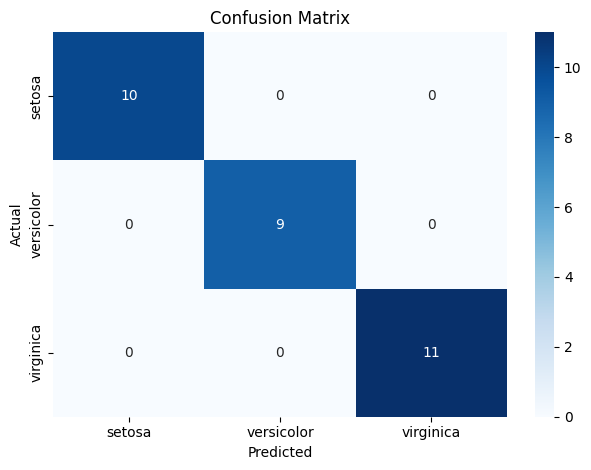

In [ ]:
# 6
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ["setosa", "versicolor", "virginica"]

cm = confusion_matrix(y_test, preds)
print(cm)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=class_names,yticklabels=class_names,)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("sklearn_cm.png", dpi=100)
plt.show()

In [ ]:
#7
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
for k in [1, 5, 15]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_s))
    print(f"KNN (k={k}) Accuracy: {acc:.2f}")

KNN (k=1) Accuracy: 1.00
KNN (k=5) Accuracy: 1.00
KNN (k=15) Accuracy: 1.00


In [ ]:
#8
from sklearn.tree import DecisionTreeClassifier
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
iris = load_iris()
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train_s, y_train)
print(f"Accuracy: {accuracy_score(y_test, dt.predict(X_test_s)):.2f}")
importances = dt.feature_importances_
idx = np.argsort(importances)[::-1]
for i in idx:
    print(f"{iris.feature_names[i]:25s}: {importances[i]:.4f}")

Accuracy: 1.00
petal length (cm)        : 0.9346
petal width (cm)         : 0.0654
sepal width (cm)         : 0.0000
sepal length (cm)        : 0.0000


In [ ]:
#9
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X,y = housing.data, housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

lr = LinearRegression()
lr.fit(X_train,y_train)
preds = lr.predict(X_test)

print(f'MSE : {mean_squared_error(y_test, preds):.2f}')
print(f'R2 : {r2_score(y_test, preds):.2f}')

MSE : 0.56
R2 : 0.58


In [ ]:
# 10
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf.fit(X_train_s, y_train)
print(f"Test Accuracy: {accuracy_score(y_test, rf.predict(X_test_s)):.2f}")
print(f"OOB Score: {rf.oob_score_:.2f}")
idx = np.argsort(rf.feature_importances_)[::-1]
print("Top features :", [iris.feature_names[i] for i in idx[:2]])

Test Accuracy: 1.00
OOB Score: 0.92
Top features : ['petal length (cm)', 'petal width (cm)']


In [ ]:
# 11
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=200, random_state=42))
])
pipe.fit(X_train,y_train)
print('Accuracy:', accuracy_score(y_test,pipe.predict(X_test)))
print('steps:',pipe.steps)

Accuracy: 1.0
steps: [('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=200, random_state=42))]


In [ ]:
# 12
from sklearn.model_selection import  cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
import numpy as np


iris = load_iris()
X, y = iris.data, iris.target


pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=200, random_state=42))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
print('fold scores:', scores.round(2))
print(f'mean:,{scores.mean():.2f} std: {scores.std():.3f}')


fold scores: [1.   0.97 0.9  1.   0.9 ]
mean:,0.95 std: 0.045


In [ ]:
# 13
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV, train_test_split

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

pipe = Pipeline(steps=[('scaler', StandardScaler()),('model', SVC())])
param_grid = {
    'model__kernel':['linear','rbf'],
    'model__C'     :    [0.1,1,10]
    }
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print('best params :', grid.best_params_)
print('best CV acc :', round(grid.best_score_, 2))
print('test accuracy :', round(grid.score(X_test,y_test),2))

best params : {'model__C': 0.1, 'model__kernel': 'linear'}
best CV acc : 0.96
test accuracy : 1.0


AUC Score:1.00


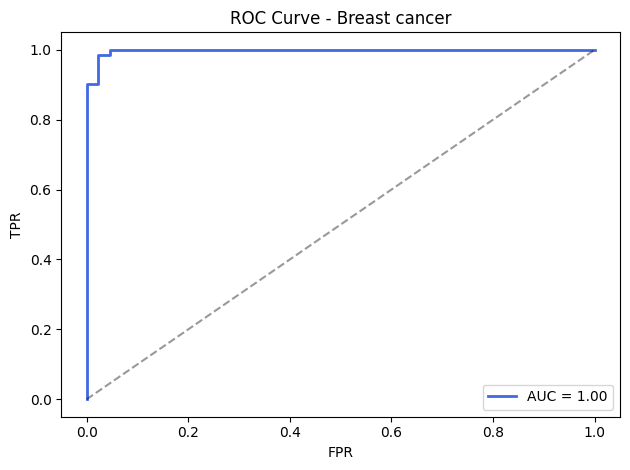

In [ ]:
# 14
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

X,y = load_breast_cancer(return_X_y=True)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)
pipe = Pipeline([('sc',StandardScaler()),
                  ('lr',LogisticRegression(max_iter=1000,random_state=42))
                  ])
pipe.fit(X_train,y_train)
proba = pipe.predict_proba(X_test)[:,1]
fpr,tpr,_ = roc_curve(y_test,proba)
auc = roc_auc_score(y_test,proba)
print(f'AUC Score:{auc:.2f}')

plt.figure()
plt.plot(fpr,tpr,label=f'AUC = {auc:.2f}',color='royalblue',linewidth=2)
plt.plot([0,1],[0,1],'k--',alpha=0.4)
plt.title('ROC Curve - Breast cancer')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.tight_layout()
plt.savefig('sklearn_roc.png',dpi=100)
plt.show()

Logistic Regression   : 0.95 +/- 0.05
KNN(k=5)              : 0.97 +/- 0.02
Decision Trees        : 0.95 +/- 0.03
Random Forest         : 0.95 +/- 0.03


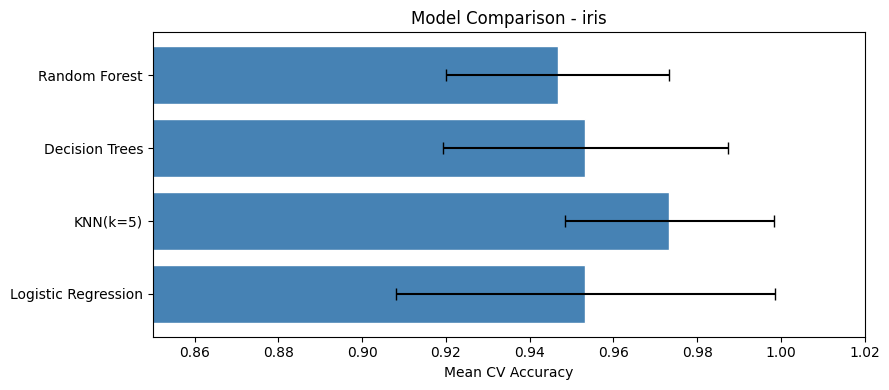

In [2]:
# 15
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.datasets import load_iris
import numpy as np, matplotlib.pyplot as plt

X,y = load_iris(return_X_y=True)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'KNN(k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Trees': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}
means, stds, names = [], [], []
for name, model in models.items():
  pipe = Pipeline([('sc', StandardScaler()),('m', model)])
  scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
  means.append(scores.mean())
  stds.append(scores.std())
  names.append(name)
  print(f'{name:<22}: {scores.mean():.2f} +/- {scores.std():.2f}')

plt.figure(figsize=(9,4))
plt.barh(names, means, xerr=stds, color='steelblue', edgecolor='white', capsize=4)
plt.xlabel('Mean CV Accuracy')
plt.title('Model Comparison - iris')
plt.xlim(0.85,1.02)
plt.tight_layout()
plt.savefig('sklearn_compare.png',dpi=100)
plt.show()